## HW 3 — Water O–H Bond Scan: Deriving the O–H Force Constant

**Objective**: Perform a constrained O–H bond length scan in water and extract the harmonic force constant from the resulting potential energy curve.

### Background

Molecular mechanics force fields represent covalent bonds as harmonic springs:  
V(r) = ½ k (r − r₀)²  
where k is the force constant (units: kcal mol⁻¹ Å⁻²) and r₀ is the equilibrium bond length. DFT calculations provide a first-principles reference for these parameters by scanning the bond potential energy surface.

### Tasks

1. **Geometry Optimization of Water**  
   - Optimize H₂O at B3LYP/def2-TZVP.  
   - Record the equilibrium O–H bond length r₀ and H–O–H angle.

2. **O–H Bond Length Scan**  
   - Fix one O–H bond length and vary it from 0.70 Å to 1.40 Å in steps of 0.05 Å.  
   - At each step, perform a single-point energy calculation (or relax all other degrees of freedom).  
   - Collect the relative energy ΔE = E(r) − E(r₀) in kcal/mol.

3. **Harmonic Fit**  
   - Fit the DFT energies near the minimum (e.g., r₀ ± 0.15 Å) to V(r) = ½ k (r − r₀)².  
   - Extract the O–H force constant k in kcal mol⁻¹ Å⁻².  
   - Convert to SI units (N/m) for comparison with experiment (k_exp ≈ 780 N/m for O–H).

4. **Comparison with Vibrational Frequency**  
   - Compute the harmonic vibrational frequency from your fitted k:  
     ν = (1/2π) √(k/μ), where μ = m_O m_H / (m_O + m_H) is the reduced mass.  
   - Compare to the B3LYP/def2-TZVP harmonic frequency from a normal-mode analysis.  
   - Compare to the experimental O–H stretch frequency (~3657 cm⁻¹ for the symmetric stretch).

5. **Morse Potential Fit** *(Optional)*  
   - Fit the full scan to a Morse potential: V(r) = D_e [1 − e^(−α(r−r₀))]².  
   - Extract D_e (dissociation energy) and α, and compare D_e to the O–H bond dissociation energy (~119 kcal/mol).


In [1]:
import os
print(os.listdir('.'))
print(os.path.exists('water_opt.xyz'))

['water_opt.out', 'h1.ipynb', 'water_opt.xyz', 'HW.md', 'CoPC.xyz', 'CoPC_opt.xyz', 'h4.ipynb', '.ipynb_checkpoints', 'h3.ipynb', 'water_scan.out', 'h2.ipynb', 'CoPC_opt.out']
True


In [2]:
with open('water_opt.xyz') as f:
    print(f.read())

3
Coordinates from ORCA-job water_opt E -76.426058640996
  O           0.00000000000000      0.00000002202448      0.11626373422100
  H           0.00000000000000      0.76520797771633     -0.46824785866291
  H           0.00000000000000     -0.76520799974081     -0.46824787555809



In [3]:
import numpy as np

atoms = []
with open('water_opt.xyz') as f:
    lines = f.readlines()
for line in lines[2:]:
    parts = line.split()
    if len(parts) >= 4:
        atoms.append((parts[0], float(parts[1]), float(parts[2]), float(parts[3])))

coords = np.array([a[1:] for a in atoms])
O, H1, H2 = coords[0], coords[1], coords[2]

r_OH1 = np.linalg.norm(H1 - O)
r_OH2 = np.linalg.norm(H2 - O)
r0 = (r_OH1 + r_OH2) / 2

v1 = H1 - O
v2 = H2 - O
angle = np.degrees(np.arccos(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))))

print("Task 1: Optimized Water Geometry (B3LYP/def2-TZVP)")
print("=" * 50)
print(f"  O-H1 bond length:  {r_OH1:.4f} Ang")
print(f"  O-H2 bond length:  {r_OH2:.4f} Ang")
print(f"  Mean r0:           {r0:.4f} Ang")
print(f"  H-O-H angle:       {angle:.2f} deg")
print(f"\n  Literature r0:     0.9572 Ang")
print(f"  Literature angle:  104.52 deg")

Task 1: Optimized Water Geometry (B3LYP/def2-TZVP)
  O-H1 bond length:  0.9629 Ang
  O-H2 bond length:  0.9629 Ang
  Mean r0:           0.9629 Ang
  H-O-H angle:       105.25 deg

  Literature r0:     0.9572 Ang
  Literature angle:  104.52 deg


In [4]:
import re

with open('water_scan.out') as f:
    content = f.read()

#single-point energies
energies_raw = re.findall(r'FINAL SINGLE POINT ENERGY\s+([-\d.]+)', content)
E_all = np.array([float(e) for e in energies_raw])

#The scan has 15 steps. ORCA prints intermediate scf energies too,
# but the FINAL SINGLE POINT ENERGY at each scan step is what we want.
#For a relaxed scan, ORCA prints one final energy per scan step,
# plus possibly extras from the initial optimization steps within each scan point.
print(f"Total FINAL SINGLE POINT ENERGY entries found: {len(E_all)}")

#For a relaxed scan, each scan step may have multiple optimization cycles.
#The energy we want is the last one before each new scan step starts.
scan_steps = [m.start() for m in re.finditer(r'RELAXED SURFACE SCAN STEP', content)]
print(f"Number of scan steps found: {len(scan_steps)}")
scan_energies = []
for i in range(len(scan_steps)):
    if i < len(scan_steps) - 1:
        block = content[scan_steps[i]:scan_steps[i+1]]
    else:
        block = content[scan_steps[i]:]
    
    block_energies = re.findall(r'FINAL SINGLE POINT ENERGY\s+([-\d.]+)', block)
    if block_energies:
        scan_energies.append(float(block_energies[-1]))  

E_scan = np.array(scan_energies)
r_scan = np.linspace(0.70, 1.40, 15)

# Convert to relative energy in kcal/mol
E_min = E_scan.min()
E_rel = (E_scan - E_min) * 627.509

print(f"\nScan energies extracted: {len(E_scan)} points")
print(f"\n{'r (Ang)':>10s}  {'E (Hartree)':>16s}  {'dE (kcal/mol)':>14s}")
print("-" * 45)
for ri, Ei, dEi in zip(r_scan, E_scan, E_rel):
    marker = " <-- minimum" if Ei == E_min else ""
    print(f"{ri:10.4f}  {Ei:16.6f}  {dEi:14.2f}{marker}")

Total FINAL SINGLE POINT ENERGY entries found: 61
Number of scan steps found: 15

Scan energies extracted: 15 points

   r (Ang)       E (Hartree)   dE (kcal/mol)
---------------------------------------------
    0.7000        -76.298781           79.77
    0.7500        -76.353768           45.26
    0.8000        -76.389128           23.07
    0.8500        -76.410473            9.68
    0.9000        -76.421780            2.58
    0.9500        -76.425896            0.00 <-- minimum
    1.0000        -76.424877            0.64
    1.0500        -76.420229            3.56
    1.1000        -76.413058            8.06
    1.1500        -76.404182           13.63
    1.2000        -76.394197           19.89
    1.2500        -76.383545           26.58
    1.3000        -76.372544           33.48
    1.3500        -76.361431           40.45
    1.4000        -76.350374           47.39


Task 3: Harmonic Fit Results
  Fitted r_eq:       0.9773 Ang
  Force constant k:  1129.3 kcal/(mol*Ang^2)
  Force constant k:  784.6 N/m
  Experimental k:    780 N/m
  Deviation:         0.6%


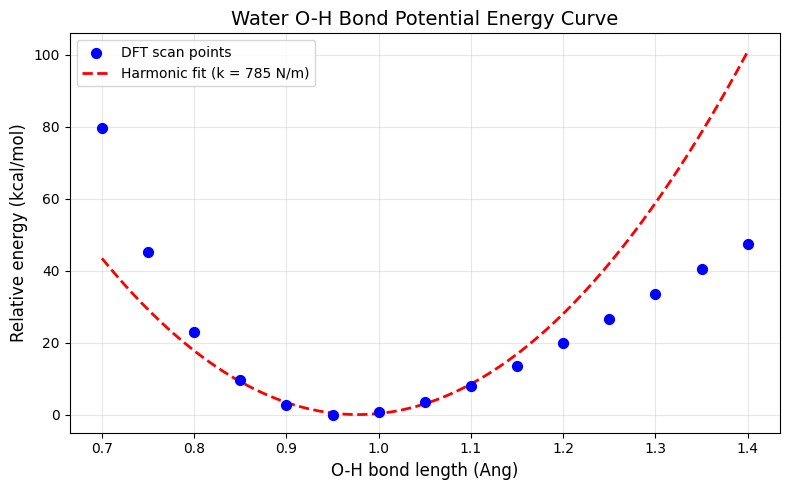

In [6]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

r0_opt = 0.9629  

mask = np.abs(r_scan - r0_opt) < 0.16
r_fit = r_scan[mask]
E_fit = E_rel[mask]
def harmonic(r, k, r_eq):
    return 0.5 * k * (r - r_eq)**2

popt, pcov = curve_fit(harmonic, r_fit, E_fit, p0=[1000, 0.96])
k_kcal = popt[0]
r_eq_fit = popt[1]

k_N_m = k_kcal * 4184 / 6.022e23 / 1e-20

print("Task 3: Harmonic Fit Results")
print("=" * 50)
print(f"  Fitted r_eq:       {r_eq_fit:.4f} Ang")
print(f"  Force constant k:  {k_kcal:.1f} kcal/(mol*Ang^2)")
print(f"  Force constant k:  {k_N_m:.1f} N/m")
print(f"  Experimental k:    780 N/m")
print(f"  Deviation:         {abs(k_N_m - 780)/780 * 100:.1f}%")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(r_scan, E_rel, color='blue', s=50, zorder=3, label='DFT scan points')
r_smooth = np.linspace(0.70, 1.40, 200)
ax.plot(r_smooth, harmonic(r_smooth, *popt), 'r--', linewidth=2,
        label=f'Harmonic fit (k = {k_N_m:.0f} N/m)')
ax.set_xlabel('O-H bond length (Ang)', fontsize=12)
ax.set_ylabel('Relative energy (kcal/mol)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_title('Water O-H Bond Potential Energy Curve', fontsize=14)
plt.tight_layout()
plt.savefig('water_OH_harmonic.png', dpi=150)
plt.show()

In [7]:

# Task 4:

m_O = 15.999#amu
m_H = 1.008#amu
mu_amu = m_O * m_H / (m_O + m_H)

mu_kg = mu_amu * 1.66054e-27  
k_SI = k_N_m  

nu_Hz = (1 / (2 * np.pi)) * np.sqrt(k_SI / mu_kg)
c_cm = 2.998e10  
nu_cm = nu_Hz / c_cm
print("Task 4: Vibrational Frequency from Fitted k")
print("=" * 50)
print(f"  Reduced mass mu:       {mu_amu:.4f} amu")
print(f"  mu in kg:              {mu_kg:.4e} kg")
print(f"  k:                     {k_N_m:.1f} N/m")
print(f"")
print(f"  nu (from fitted k):    {nu_cm:.0f} cm^-1")
print(f"  Experimental (sym):    3657 cm^-1")
print(f"  Deviation:             {abs(nu_cm - 3657)/3657 * 100:.1f}%")

Task 4: Vibrational Frequency from Fitted k
  Reduced mass mu:       0.9483 amu
  mu in kg:              1.5746e-27 kg
  k:                     784.6 N/m

  nu (from fitted k):    3747 cm^-1
  Experimental (sym):    3657 cm^-1
  Deviation:             2.5%


In [9]:

# Task 4 
nu_bend = 1615.75   
nu_sym  = 3781.38   
nu_asym = 3886.21    

nu_fitted = 3747     # cm^-1

#experimental values
nu_exp_bend = 1595  
nu_exp_sym  = 3657   
nu_exp_asym = 3756  

print("Task 4: Vibrational Frequency Comparison")
print("=" * 65)
print(f"{'Mode':<25s} {'Fitted k':>10s} {'DFT Freq':>10s} {'Expt':>10s}")
print("-" * 65)
print(f"{'H-O-H bend':<25s} {'---':>10s} {nu_bend:>10.1f} {nu_exp_bend:>10.0f}")
print(f"{'O-H symmetric stretch':<25s} {nu_fitted:>10.0f} {nu_sym:>10.1f} {nu_exp_sym:>10.0f}")
print(f"{'O-H asymmetric stretch':<25s} {'---':>10s} {nu_asym:>10.1f} {nu_exp_asym:>10.0f}")
print("-" * 65)

print(f"\nFitted k vs DFT (sym stretch):  {abs(nu_fitted - nu_sym):.0f} cm^-1 difference")
print(f"DFT vs Experiment (sym stretch): {abs(nu_sym - nu_exp_sym):.0f} cm^-1 ({abs(nu_sym - nu_exp_sym)/nu_exp_sym*100:.1f}% error)")
print(f"Fitted k vs Experiment:          {abs(nu_fitted - nu_exp_sym):.0f} cm^-1 ({abs(nu_fitted - nu_exp_sym)/nu_exp_sym*100:.1f}% error)")

print(f"\nNote: DFT harmonic frequencies overestimate experiment by ~3-5%")
print(f"because they neglect anharmonicity. Empirical scaling factors")
print(f"(e.g., 0.965 for B3LYP) are commonly applied to correct this.")
print(f"\nScaled DFT symmetric stretch: {nu_sym * 0.965:.0f} cm^-1 (vs expt {nu_exp_sym} cm^-1)")

Task 4: Vibrational Frequency Comparison
Mode                        Fitted k   DFT Freq       Expt
-----------------------------------------------------------------
H-O-H bend                       ---     1615.8       1595
O-H symmetric stretch           3747     3781.4       3657
O-H asymmetric stretch           ---     3886.2       3756
-----------------------------------------------------------------

Fitted k vs DFT (sym stretch):  34 cm^-1 difference
DFT vs Experiment (sym stretch): 124 cm^-1 (3.4% error)
Fitted k vs Experiment:          90 cm^-1 (2.5% error)

Note: DFT harmonic frequencies overestimate experiment by ~3-5%
because they neglect anharmonicity. Empirical scaling factors
(e.g., 0.965 for B3LYP) are commonly applied to correct this.

Scaled DFT symmetric stretch: 3649 cm^-1 (vs expt 3657 cm^-1)


Task 5: Morse Potential Fit
  De (dissociation energy): 117.5 kcal/mol
  alpha:                    2.277 Ang^-1
  r0 (Morse):               0.9631 Ang

  Experimental De (O-H):    ~119 kcal/mol
  Deviation:                1.3%

  k from Morse (2*De*alpha^2): 1218.5 kcal/(mol*Ang^2)
  k from Morse:                846.6 N/m
  k from harmonic fit:         784.6 N/m


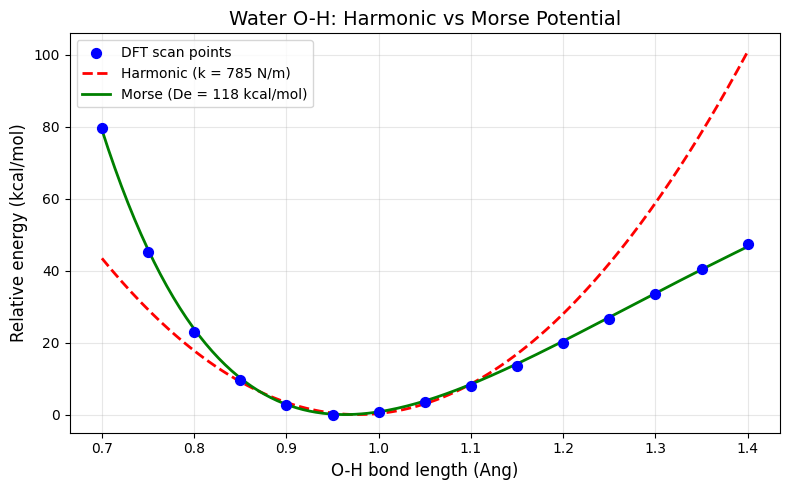

In [8]:

# Task 5
def morse(r, De, alpha, r0_morse):
    return De * (1 - np.exp(-alpha * (r - r0_morse)))**2

popt_morse, pcov_morse = curve_fit(morse, r_scan, E_rel, p0=[120, 2.5, 0.96])
De, alpha, r0_morse = popt_morse

print("Task 5: Morse Potential Fit")
print("=" * 50)
print(f"  De (dissociation energy): {De:.1f} kcal/mol")
print(f"  alpha:                    {alpha:.3f} Ang^-1")
print(f"  r0 (Morse):               {r0_morse:.4f} Ang")
print(f"")
print(f"  Experimental De (O-H):    ~119 kcal/mol")
print(f"  Deviation:                {abs(De - 119)/119 * 100:.1f}%")

k_morse_kcal = 2 * De * alpha**2
k_morse_Nm = k_morse_kcal * 4184 / 6.022e23 / 1e-20

print(f"\n  k from Morse (2*De*alpha^2): {k_morse_kcal:.1f} kcal/(mol*Ang^2)")
print(f"  k from Morse:                {k_morse_Nm:.1f} N/m")
print(f"  k from harmonic fit:         {k_N_m:.1f} N/m")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(r_scan, E_rel, color='blue', s=50, zorder=3, label='DFT scan points')

r_smooth = np.linspace(0.70, 1.40, 200)
ax.plot(r_smooth, harmonic(r_smooth, *popt), 'r--', linewidth=2,
        label=f'Harmonic (k = {k_N_m:.0f} N/m)')
ax.plot(r_smooth, morse(r_smooth, *popt_morse), 'g-', linewidth=2,
        label=f'Morse (De = {De:.0f} kcal/mol)')

ax.set_xlabel('O-H bond length (Ang)', fontsize=12)
ax.set_ylabel('Relative energy (kcal/mol)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_title('Water O-H: Harmonic vs Morse Potential', fontsize=14)
plt.tight_layout()
plt.savefig('water_OH_morse.png', dpi=150)
plt.show()

In [10]:
import py3Dmol

O  = np.array([0.0, 0.0, 0.11626])
H2 = np.array([0.0, -0.76521, -0.46825])

H1_opt = np.array([0.0, 0.76521, -0.46825])
direction = (H1_opt - O) / np.linalg.norm(H1_opt - O)

frames = ""
for r, dE in zip(r_scan, E_rel):
    H1_pos = O + direction * r
    frames += f"3\n"
    frames += f"r_OH = {r:.2f} Ang | dE = {dE:.2f} kcal/mol\n"
    frames += f"O  {O[0]:.6f}  {O[1]:.6f}  {O[2]:.6f}\n"
    frames += f"H  {H1_pos[0]:.6f}  {H1_pos[1]:.6f}  {H1_pos[2]:.6f}\n"
    frames += f"H  {H2[0]:.6f}  {H2[1]:.6f}  {H2[2]:.6f}\n"

view = py3Dmol.view(width=600, height=400)
view.addModelsAsFrames(frames, 'xyz')
view.setStyle({'stick': {'radius': 0.15}, 'sphere': {'scale': 0.3}})
view.setBackgroundColor('white')
view.zoomTo()
view.animate({'loop': 'forward', 'interval': 500})  # 500ms per frame
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [12]:

#electrostatic Potential Surface of Water

import py3Dmol

with open('water_opt.xyz') as f:
    water_xyz = f.read()

view = py3Dmol.view(width=600, height=450)
view.addModel(water_xyz, 'xyz')

view.setStyle({'stick': {'radius': 0.15}, 'sphere': {'scale': 0.25}})

view.addSurface(py3Dmol.VDW, {
    'opacity': 0.7,
    'colorscheme': {
        'gradient': 'rwb',   # red-white-blue gradient
        'min': -0.05,
        'max': 0.05
    }
})
view.setBackgroundColor('white')
view.zoomTo()
view.show()

print("ESP surface: red = electron-rich (near O), blue = electron-poor (near H)")


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

ESP surface: red = electron-rich (near O), blue = electron-poor (near H)
